## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("unified_features_v3.csv")
print(f"Total rows loaded: {len(df)}")
print(df["traffic_source"].value_counts())
df.head()

Total rows loaded: 1039
traffic_source
DCC_2024_2025    973
SDCC_2024         65
DLR_2023           1
Name: count, dtype: int64


,location_id,lat,lon,traffic_volume,traffic_source,distance_to_nearest_substation_m,charger_count_nearby,road_density,ev_penetration_proxy
0,1,53.348754,-6.257607,241.52,DCC_2024_2025,31.6,0,219,0.049
1,2,53.354711,-6.246679,1540.22,DCC_2024_2025,36.1,0,63,0.049
2,3,53.351374,-6.250073,833.42,DCC_2024_2025,20.1,0,138,0.049
3,4,53.361145,-6.240513,289.96,DCC_2024_2025,67.7,0,49,0.049
4,5,53.355797,-6.292406,769.61,DCC_2024_2025,167.2,1,24,0.049


## 2. Separate SDCC (Display-Only)

SDCC uses SCOOT sensor system; DCC/DLR use SCATS. Mean traffic volume: SDCC=142 vs DCC=701 (~5x difference). Excluded from clustering; shown on map only.

In [2]:
df_sdcc    = df[df["traffic_source"] == "SDCC_2024"].copy()
df_cluster = df[df["traffic_source"] != "SDCC_2024"].copy().reset_index(drop=True)

print(f"Clustering dataset : {len(df_cluster)} rows (DCC + DLR)")
print(f"SDCC display-only  : {len(df_sdcc)} rows")
print(f"DCC/DLR mean traffic : {df_cluster['traffic_volume'].mean():.1f}")
print(f"SDCC mean traffic    : {df_sdcc['traffic_volume'].mean():.1f}")

Clustering dataset : 974 rows (DCC + DLR)
SDCC display-only  : 65 rows
DCC/DLR mean traffic : 700.8
SDCC mean traffic    : 142.1


## 3. Feature Engineering — Gap Score

`gap_score = traffic_volume / (charger_count_nearby + 1)`

Higher score = high demand, low existing supply = priority candidate.

In [3]:
df_cluster["gap_score"] = (
    df_cluster["traffic_volume"] / (df_cluster["charger_count_nearby"] + 1)
)
print("Gap Score statistics:")
print(df_cluster["gap_score"].describe())

Gap Score statistics:
count     974.000000
mean      544.962229
std       524.613235
min         0.000000
25%       185.690833
50%       421.301667
75%       795.037500
max      7731.500000
Name: gap_score, dtype: float64


## 4. Select Top 20% Candidates by Gap Score

In [4]:
threshold = df_cluster["gap_score"].quantile(0.80)
df_priority = df_cluster[df_cluster["gap_score"] >= threshold].copy().reset_index(drop=True)

print(f"Gap score threshold (80th percentile): {threshold:.2f}")
print(f"Candidate sites selected: {len(df_priority)} / {len(df_cluster)}")

Gap score threshold (80th percentile): 891.43
Candidate sites selected: 195 / 974


## 5. Elbow Method — Select Optimal K

Features used:
- `traffic_volume` — demand proxy
- `charger_count_nearby` — existing supply
- `road_density` — road network density
- `distance_to_nearest_substation_m` — grid accessibility / renewable energy proxy (NEW in v3)
- `lat`, `lon` — spatial position

Excluded: `ev_penetration_proxy` (constant 0.049, zero spatial variance)

Features: ['traffic_volume', 'charger_count_nearby', 'road_density', 'distance_to_nearest_substation_m', 'lat', 'lon']
Input shape: (195, 6)


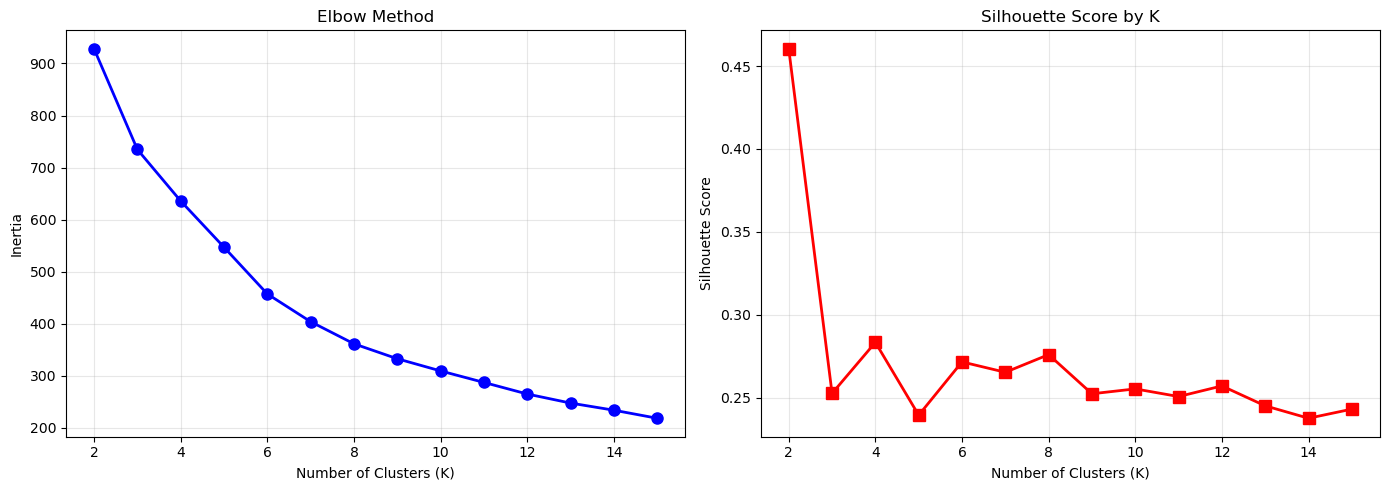


Silhouette scores by K:
  K= 2: 0.4604
  K= 3: 0.2526
  K= 4: 0.2834
  K= 5: 0.2395
  K= 6: 0.2716
  K= 7: 0.2653
  K= 8: 0.2760
  K= 9: 0.2524
  K=10: 0.2553
  K=11: 0.2507
  K=12: 0.2571
  K=13: 0.2451
  K=14: 0.2376
  K=15: 0.2431


In [5]:
FEATURES = [
    "traffic_volume",
    "charger_count_nearby",
    "road_density",
    "distance_to_nearest_substation_m",
    "lat",
    "lon"
]

X = df_priority[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {FEATURES}")
print(f"Input shape: {X_scaled.shape}")

inertias = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.grid(True, alpha=0.3)
ax2.plot(K_range, sil_scores, "rs-", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score by K")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_silhouette_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    print(f"  K={k:2d}: {s:.4f}")

## 6. Final K-Means

In [6]:
# Select K based on elbow plot above
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_priority["cluster"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df_priority["cluster"])
print(f"Silhouette Score (K={K}): {score:.4f}")
print(f"\nVersion comparison:")
print(f"  v1 — 223 sites, DLR only, no substation feature  : 0.4235")
print(f"  v2 — 974 sites, DCC+DLR, no substation feature   : 0.3287")
print(f"  v3 — 974 sites, DCC+DLR, with substation feature : {score:.4f}")
print(f"\nCluster sizes:")
print(df_priority["cluster"].value_counts().sort_index())

Silhouette Score (K=10): 0.2553

Version comparison:
  v1 — 223 sites, DLR only, no substation feature  : 0.4235
  v2 — 974 sites, DCC+DLR, no substation feature   : 0.3287
  v3 — 974 sites, DCC+DLR, with substation feature : 0.2553

Cluster sizes:
cluster
0    51
1    23
2    24
3    13
4     1
5     9
6     4
7    40
8    10
9    20
Name: count, dtype: int64


## 7. Select Top Recommendation per Cluster

In [7]:
cluster_centers = (
    df_priority
    .sort_values("gap_score", ascending=False)
    .groupby("cluster")
    .first()
    .reset_index()
)
cluster_centers = cluster_centers.sort_values("gap_score", ascending=False).reset_index(drop=True)
cluster_centers["rank"] = cluster_centers.index + 1

cols = ["rank","lat","lon","cluster","gap_score","traffic_volume","charger_count_nearby","road_density","distance_to_nearest_substation_m"]
print("Top 10 Recommendations:")
print(cluster_centers[cols].to_string(index=False))

Top 10 Recommendations:
 rank       lat       lon  cluster  gap_score  traffic_volume  charger_count_nearby  road_density  distance_to_nearest_substation_m
    1 53.425378 -6.219091        4   7731.500         7731.50                     0             3                             138.2
    2 53.343710 -6.308068        7   3157.070         3157.07                     0            95                             106.0
    3 53.272522 -6.219414        9   2554.250         2554.25                     0            73                             143.3
    4 53.352471 -6.224958        0   2499.740         2499.74                     0            39                              75.5
    5 53.278474 -6.185137        1   2469.890         2469.89                     0             8                              72.3
    6 53.351254 -6.225855        2   2404.470         2404.47                     0            43                              26.7
    7 53.382460 -6.244531        8   2143.840       

## 8. Export recommendations.csv

In [8]:
out_cols = [
    "rank", "lat", "lon", "cluster",
    "gap_score", "traffic_volume",
    "charger_count_nearby", "road_density",
    "distance_to_nearest_substation_m",
    "traffic_source"
]
cluster_centers[out_cols].to_csv("recommendations.csv", index=False)
print("Saved: recommendations.csv")
print(cluster_centers[out_cols].to_string(index=False))

Saved: recommendations.csv
 rank       lat       lon  cluster  gap_score  traffic_volume  charger_count_nearby  road_density  distance_to_nearest_substation_m traffic_source
    1 53.425378 -6.219091        4   7731.500         7731.50                     0             3                             138.2  DCC_2024_2025
    2 53.343710 -6.308068        7   3157.070         3157.07                     0            95                             106.0  DCC_2024_2025
    3 53.272522 -6.219414        9   2554.250         2554.25                     0            73                             143.3  DCC_2024_2025
    4 53.352471 -6.224958        0   2499.740         2499.74                     0            39                              75.5  DCC_2024_2025
    5 53.278474 -6.185137        1   2469.890         2469.89                     0             8                              72.3  DCC_2024_2025
    6 53.351254 -6.225855        2   2404.470         2404.47                     0        

## 9. Folium Map

In [9]:
COLORS = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "darkpurple", "darkblue"
]

m = folium.Map(location=[53.33, -6.25], zoom_start=11)

# All DCC+DLR sites (grey)
for _, row in df_cluster.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3, color="lightgrey", fill=True, fill_opacity=0.3
    ).add_to(m)

# SDCC sites (blue outline, display only)
for _, row in df_sdcc.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4, color="steelblue", fill=False, weight=1.5,
        popup=f"SDCC (display only)<br>Traffic: {row['traffic_volume']:.0f}"
    ).add_to(m)

# Priority candidates (coloured by cluster)
for _, row in df_priority.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5, color=COLORS[int(row["cluster"])], fill=True, fill_opacity=0.5,
        popup=(
            f"Traffic: {row['traffic_volume']:.0f}<br>"
            f"Gap Score: {row['gap_score']:.1f}<br>"
            f"Substation dist: {row['distance_to_nearest_substation_m']:.0f}m<br>"
            f"Cluster: {int(row['cluster'])}"
        )
    ).add_to(m)

# Recommendations (red bolt markers)
for _, row in cluster_centers.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=(
            f"Rank #{int(row['rank'])}<br>"
            f"Gap Score: {row['gap_score']:.1f}<br>"
            f"Traffic: {row['traffic_volume']:.0f}<br>"
            f"Nearest substation: {row['distance_to_nearest_substation_m']:.0f}m"
        ),
        icon=folium.Icon(color="red", icon="bolt", prefix="fa")
    ).add_to(m)

m.save("kmeans_recommendations_v3.html")
print("Map saved: kmeans_recommendations_v3.html")
m

Map saved: kmeans_recommendations_v3.html


## 10. Summary

In [10]:
print("=== K-Means Clustering Summary (v3) ===")
print(f"Total sites loaded           : {len(df)}")
print(f"SDCC excluded (display only) : {len(df_sdcc)}")
print(f"Clustering dataset           : {len(df_cluster)} (DCC + DLR)")
print(f"Priority sites (top 20%)     : {len(df_priority)}")
print(f"Features used                : {FEATURES}")
print(f"Number of clusters (K)       : {K}")
print(f"Silhouette Score             : {score:.4f}")
print(f"Recommended locations        : {len(cluster_centers)}")
print()
print("Top 3 recommendations:")
for _, row in cluster_centers.head(3).iterrows():
    print(f"  Rank #{int(row['rank'])}: ({row['lat']:.4f}, {row['lon']:.4f}) — Gap Score: {row['gap_score']:.1f} — Substation: {row['distance_to_nearest_substation_m']:.0f}m")

=== K-Means Clustering Summary (v3) ===
Total sites loaded           : 1039
SDCC excluded (display only) : 65
Clustering dataset           : 974 (DCC + DLR)
Priority sites (top 20%)     : 195
Features used                : ['traffic_volume', 'charger_count_nearby', 'road_density', 'distance_to_nearest_substation_m', 'lat', 'lon']
Number of clusters (K)       : 10
Silhouette Score             : 0.2553
Recommended locations        : 10

Top 3 recommendations:
  Rank #1: (53.4254, -6.2191) — Gap Score: 7731.5 — Substation: 138m
  Rank #2: (53.3437, -6.3081) — Gap Score: 3157.1 — Substation: 106m
  Rank #3: (53.2725, -6.2194) — Gap Score: 2554.2 — Substation: 143m
